In [1]:
import os
import re
import numpy as np
import time
import random
import pandas as pd
import glob
import shutil
import seaborn as sns
import itertools
import math
from pathlib import Path
import json
from copy import deepcopy
from dataclasses import dataclass
from types import SimpleNamespace

from matplotlib.lines import Line2D
from scipy.integrate import solve_ivp
from sklearn.metrics import confusion_matrix
from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from autocatalytic_cores_lib import *
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import linregress
from scipy.optimize import newton_krylov
from scipy.optimize import broyden1
from scipy.optimize import anderson
from scipy.optimize._nonlin import NoConvergence
from sympy import symbols, Matrix, diff, lambdify
from scipy.linalg import eigvals
from numpy.linalg import svd
from scipy.optimize import linprog
from scipy.sparse import csr_matrix
from scipy.sparse import bmat
from scipy.sparse.csgraph import connected_components
from scipy.linalg import eigh
from scipy.optimize import fsolve
from textwrap import dedent
import networkx as nx   
from matplotlib import animation

In [2]:
class Neumann(object):

    """
    This class describes the Generalized von Neumann growth model as it was
    discussed in Kemeny et al. (1956, ECTA) and Gale (1960, Chapter 9.5):

    Let:
    n ... number of goods
    m ... number of activities
    A ... input matrix is m-by-n
        a_{i,j} - amount of good j consumed by activity i
    B ... output matrix is m-by-n
        b_{i,j} - amount of good j produced by activity i

    x ... intensity vector (m-vector) with non-negative entries
        x'B - the vector of goods produced
        x'A - the vector of goods consumed
    p ... price vector (n-vector) with non-negative entries
        Bp - the revenue vector for every activity
        Ap - the cost of each activity

    Both A and B have non-negative entries. Moreover, we assume that
    (1) Assumption I (every good which is consumed is also produced):
        for all j, b_{.,j} > 0, i.e. at least one entry is strictly positive
    (2) Assumption II (no free lunch):
        for all i, a_{i,.} > 0, i.e. at least one entry is strictly positive

    Parameters
    ----------
    A : array_like or scalar(float)
        Part of the state transition equation.  It should be `n x n`
    B : array_like or scalar(float)
        Part of the state transition equation.  It should be `n x k`
    """

    def __init__(self, A, B):

        self.A, self.B = list(map(self.convert, (A, B)))
        self.m, self.n = self.A.shape

        # Check if (A, B) satisfy the basic assumptions
        assert self.A.shape == self.B.shape, 'The input and output matrices \
              must have the same dimensions!'
        assert (self.A >= 0).all() and (self.B >= 0).all(), 'The input and \
              output matrices must have only non-negative entries!'

        # (1) Check whether Assumption I is satisfied:
        if (np.sum(B, 0) <= 0).any():
            self.AI = False
        else:
            self.AI = True

        # (2) Check whether Assumption II is satisfied:
        if (np.sum(A, 1) <= 0).any():
            self.AII = False
        else:
            self.AII = True

    def __repr__(self):
        return self.__str__()

    def __str__(self):

        me = """
        Generalized von Neumann expanding model:
          - number of goods          : {n}
          - number of activities     : {m}

        Assumptions:
          - AI:  every column of B has a positive entry    : {AI}
          - AII: every row of A has a positive entry       : {AII}

        """
        # Irreducible                                       : {irr}
        return dedent(me.format(n=self.n, m=self.m,
                                AI=self.AI, AII=self.AII))

    def convert(self, x):
        """
        Convert array_like objects (lists of lists, floats, etc.) into
        well-formed 2D NumPy arrays
        """
        return np.atleast_2d(np.asarray(x))


    def bounds(self):
        """
        Calculate the trivial upper and lower bounds for alpha (expansion rate)
        and beta (interest factor). See the proof of Theorem 9.8 in Gale (1960)
        """

        n, m = self.n, self.m
        A, B = self.A, self.B

        f = lambda α: ((B - α * A) @ np.ones((n, 1))).max()
        g = lambda β: (np.ones((1, m)) @ (B - β * A)).min()

        UB = fsolve(f, 1).item()  # Upper bound for α, β
        LB = fsolve(g, 2).item()  # Lower bound for α, β

        return LB, UB


    def zerosum(self, γ, dual=False):
        """
        Given gamma, calculate the value and optimal strategies of a
        two-player zero-sum game given by the matrix

                M(gamma) = B - gamma * A

        Row player maximizing, column player minimizing

        Zero-sum game as an LP (primal --> α)

            max (0', 1) @ (x', v)
            subject to
            [-M', ones(n, 1)] @ (x', v)' <= 0
            (x', v) @ (ones(m, 1), 0) = 1
            (x', v) >= (0', -inf)

        Zero-sum game as an LP (dual --> beta)

            min (0', 1) @ (p', u)
            subject to
            [M, -ones(m, 1)] @ (p', u)' <= 0
            (p', u) @ (ones(n, 1), 0) = 1
            (p', u) >= (0', -inf)

        Outputs:
        --------
        value: scalar
            value of the zero-sum game

        strategy: vector
            if dual = False, it is the intensity vector,
            if dual = True, it is the price vector
        """

        A, B, n, m = self.A, self.B, self.n, self.m
        M = B - γ * A

        if dual == False:
            # Solve the primal LP (for details see the description)
            # (1) Define the problem for v as a maximization (linprog minimizes)
            c = np.hstack([np.zeros(m), -1])

            # (2) Add constraints :
            # ... non-negativity constraints
            bounds = tuple(m * [(0, None)] + [(None, None)])
            # ... inequality constraints
            A_iq = np.hstack([-M.T, np.ones((n, 1))])
            b_iq = np.zeros((n, 1))
            # ... normalization
            A_eq = np.hstack([np.ones(m), 0]).reshape(1, m + 1)
            b_eq = 1

            res = linprog(c, A_ub=A_iq, b_ub=b_iq, A_eq=A_eq, b_eq=b_eq,
                          bounds=bounds)

        else:
            # Solve the dual LP (for details see the description)
            # (1) Define the problem for v as a maximization (linprog minimizes)
            c = np.hstack([np.zeros(n), 1])

            # (2) Add constraints :
            # ... non-negativity constraints
            bounds = tuple(n * [(0, None)] + [(None, None)])
            # ... inequality constraints
            A_iq = np.hstack([M, -np.ones((m, 1))])
            b_iq = np.zeros((m, 1))
            # ... normalization
            A_eq = np.hstack([np.ones(n), 0]).reshape(1, n + 1)
            b_eq = 1

            res = linprog(c, A_ub=A_iq, b_ub=b_iq, A_eq=A_eq, b_eq=b_eq,
                          bounds=bounds)

        if res.status != 0 or res.x is None:
            # LP infeasible or error
            return np.nan, None

        # Pull out the required quantities
        value = res.x[-1]
        strategy = res.x[:-1]

        return value, strategy


    def expansion(self, tol=1e-8, maxit=1000):
        """
        The algorithm used here is described in Hamburger-Thompson-Weil
        (1967, ECTA). It is based on a simple bisection argument and utilizes
        the idea that for a given γ (= α or β), the matrix "M = B - γ * A"
        defines a two-player zero-sum game, where the optimal strategies are
        the (normalized) intensity and price vector.

        Outputs:
        --------
        alpha: scalar
            optimal expansion rate
        """

        LB, UB = self.bounds()

        for iter in range(maxit):

            γ = (LB + UB) / 2
            ZS = self.zerosum(γ=γ, dual=False)
            V = ZS[0]     # value of the game with γ

            if V >= 0:
                LB = γ
            else:
                UB = γ

            if abs(UB - LB) < tol:
                γ = (UB + LB) / 2
                x = self.zerosum(γ=γ)[1]
                p = self.zerosum(γ=γ, dual=True)[1]
                break

        return γ, x, p

    def interest(self, tol=1e-8, maxit=1000):
        """
        The algorithm used here is described in Hamburger-Thompson-Weil
        (1967, ECTA). It is based on a simple bisection argument and utilizes
        the idea that for a given gamma (= alpha or beta),
        the matrix "M = B - γ * A" defines a two-player zero-sum game,
        where the optimal strategies are the (normalized) intensity and price
        vector

        Outputs:
        --------
        beta: scalar
            optimal interest rate
        """

        LB, UB = self.bounds()

        for iter in range(maxit):
            γ = (LB + UB) / 2
            ZS = self.zerosum(γ=γ, dual=True)
            V = ZS[0]

            if V > 0:
                LB = γ
            else:
                UB = γ

            if abs(UB - LB) < tol:
                γ = (UB + LB) / 2
                p = self.zerosum(γ=γ, dual=True)[1]
                x = self.zerosum(γ=γ)[1]
                break

        return γ, x, p

def compute_von_neumann_alpha_beta(S_plus, S_minus, tol=1e-8):
    """
    Compute von Neumann alpha (expansion), beta (interest),
    and the optimal normalized flows for both problems.

    Returns:
    --------
    alpha : Optimal expansion rate.
    beta : Optimal interest rate.
    x_alpha : Optimal intensity vector (normalized flow) for expansion.
    p_alpha : Optimal price vector for expansion.
    x_beta : Optimal intensity vector (normalized flow) for interest.
    p_beta : Optimal price vector for interest.
    """
    
    A = S_minus.T
    B = S_plus.T
    model = Neumann(A, B)

    # alpha
    alpha, x_alpha, p_alpha = model.expansion(tol=tol)

    # beta
    beta, x_beta, p_beta  = model.interest(tol=tol)

    return alpha, beta, x_alpha, p_alpha, x_beta, p_beta

In [3]:
import auxiliary_functions as aux

In [4]:
def Generate_Random_Network(N_Y_raw, N_R_raw, ambiguity, max_order):

    # Build Random Network
    S_raw = np.zeros((N_Y_raw, N_R_raw))
    S1_raw = np.zeros((N_Y_raw, N_R_raw))
    
    # Construct stoichiometric matrix
    for i in range(N_R_raw):
        species1 = random.randint(0, N_Y_raw - 1)
        S_raw[species1][i] += 1
        
        species2 = random.randint(0, N_Y_raw - 1)
        while not ambiguity and species2 == species1:
            species2 = random.randint(0, N_Y_raw - 1)
        S1_raw[species2][i] += 1
            
        # The order of a chemical reaction
        total_order_for = random.randint(1, max_order)
        total_order_bac = random.randint(1, max_order)
        # Count the number of forward/backward reaction species already in the reaction
        stoichio_for = 0
        stoichio_bac = 0
                
        while stoichio_for < (total_order_for - 1):
            species = random.randint(0, N_Y_raw - 1)
            if ambiguity or S1_raw[species][i] == 0:
                S_raw[species][i] += 1
                stoichio_for += 1
    
        while stoichio_bac < (total_order_bac - 1):
            species = random.randint(0, N_Y_raw - 1)
            if ambiguity or S_raw[species][i] == 0:
                S1_raw[species][i] += 1
                stoichio_bac += 1
    
    Stot_raw = S1_raw - S_raw

    '''
    Reduce Matrix to Avoid Redundant and Confusion
    '''
    
    # Remove all-zero rows (empty species)
    # Species
    row_keep = ~((S_raw==0).all(axis=1) & (S1_raw==0).all(axis=1))
    S_raw  = S_raw[row_keep]
    S1_raw = S1_raw[row_keep]

    # Remove all-zero columns (reactions with net zero stoichiometry)
    col_keep = ~((S_raw==0).all(axis=0) & (S1_raw==0).all(axis=0))
    S_raw  = S_raw[:, col_keep]
    S1_raw = S1_raw[:, col_keep]

    # Remove duplicate columns
    m = S_raw.shape[1]
    keep = []
    seen = set()
    for j in range(m):
        key = tuple(S_raw[:,j].tolist()) + tuple(S1_raw[:,j].tolist())
        if key not in seen:
            seen.add(key)
            keep.append(j)
    S_raw  = S_raw[:, keep]
    S1_raw = S1_raw[:, keep]

    '''
    # === Filter minimal stoichiometry for identical channels ===
    def filter_minimal_channels(S_minus, S_plus):
        # Keep only smallest stoichiometry for channels with identical reactants or products
        m = S_minus.shape[1]
        keep = set(range(m))
        # Group by reactant signature (columns of S_minus)
        reactant_cols = [tuple(col) for col in S_minus.T]
        for i, sig in enumerate(reactant_cols):
            # Find all channels with same reactants
            group = [j for j, s in enumerate(reactant_cols) if s == sig]
            # From these channels, keep minimal stoich for each unique single-species product
            prod_entries = []  # (j, species, count)
            for j in group:
                prod_vec = S_plus[:, j]
                nz = np.nonzero(prod_vec)[0]
                if len(nz) == 1:
                    prod_entries.append((j, nz[0], prod_vec[nz[0]]))
            if len(prod_entries) > 1:
                # Group by product species
                by_prod = {}
                for j, k, count in prod_entries:
                    by_prod.setdefault(k, []).append((j, count))
                # For each product species, keep minimal count
                for entries in by_prod.values():
                    if len(entries) > 1:
                        j_min, _ = min(entries, key=lambda x: x[1])
                        for j, _ in entries:
                            if j != j_min:
                                keep.discard(j)
        return keep

    # Apply filtering for forward channels (filtering by S_raw reactants)
    keep_fwd = filter_minimal_channels(S_raw, S1_raw)
    # Apply filtering for backward channels (filtering by S1_raw as reactants)
    keep_bwd = filter_minimal_channels(S1_raw, S_raw)
    # Intersection: channels to keep
    keep_indices = keep_fwd.intersection(keep_bwd)

    # Filter columns
    keep_list = sorted(keep_indices)
    S_raw = S_raw[:, keep_list]
    S1_raw = S1_raw[:, keep_list]
    '''

    # Record new parameters
    S_plus = S1_raw
    S_minus = S_raw
    Stot = S_plus - S_minus
    N_Y = Stot.shape[0]
    N_R = Stot.shape[1]

    df_Stot = pd.DataFrame(
    Stot.astype(int),                        
    index=range(1, Stot.shape[0]+1),         
    columns=range(1, Stot.shape[1]+1)        
    )
    #print("Matrix Stot:")
    #print(df_Stot.to_string())
    
    # S_plus 
    df_Sp = pd.DataFrame(
        S_plus.astype(int),
        index=range(1, S_plus.shape[0]+1),
        columns=range(1, S_plus.shape[1]+1)
    )
    #print("\nS_plus:")
    #print(df_Sp.to_string())
    
    # S_minus 
    df_Sm = pd.DataFrame(
        S_minus.astype(int),
        index=range(1, S_minus.shape[0]+1),
        columns=range(1, S_minus.shape[1]+1)
    )
    #print("\nS_minus:")
    #print(df_Sm.to_string())
    #print("NY =", N_Y)
    #print("NR =", N_R)

    return Stot, N_Y, N_R, S_plus, S_minus

"""
We only consider forward reactions,
we don't need to define chemical potential and delta G
"""

"\nWe only consider forward reactions,\nwe don't need to define chemical potential and delta G\n"

In [7]:
""""
Distribution of random networks
"""
def main_order_distribution():
    
    # storage
    alpha_list = []
    #beta_list = []
    #mu_list = []
    #S_plus_list = []
    #S_minus_list = []
    
    attempts = 0       
    successes = 0       
    target_num = 80
    
    while successes < target_num and attempts < 80000:
        attempts += 1
        
        # Random networks
        Stot, N_Y, N_R, S_plus, S_minus = Generate_Random_Network(
        N_Y_raw=random.randint(2, 12),
        N_R_raw=random.randint(2, 12),
        ambiguity=False,
        max_order = 2
        )

        # Check autonomy condition
        _, _, auto = aux.checkAutonomy(S_minus, S_plus)
        if not auto:
            continue
         
        # von Neumann growth factor α
        try:
            alpha, beta, _, _, _, _ = compute_von_neumann_alpha_beta(S_plus, S_minus)
        except Exception:
            continue
        if np.isnan(alpha) or np.isnan(beta):
            continue

        '''
        mu = compute_topological_growth_bound(S_minus, alpha, x_alpha)
        
        if not np.isfinite(mu):
            continue
        '''

        # save
        alpha_list.append(alpha)
        #beta_list.append(beta)
        #mu_list.append(mu)
        #S_plus_list.append(S_plus)
        #S_minus_list.append(S_minus)
        
    alpha_arr = np.array(alpha_list)
    # Save raw alpha data
    np.save("alpha_values.npy", alpha_arr)
    
    '''
    # 1) KDE on a fine grid
    kde = gaussian_kde(alpha_arr)
    
    alpha_max = 3
    x_grid = np.linspace(x_min, alpha_max, 3000)
    dens = kde(x_grid)

    # find peaks in the density curve
    peaks_idx, _ = find_peaks(dens, distance=100)  
    # distance ensure that peaks are at least (distance) grid points apart.
    peak_xs = x_grid[peaks_idx]
    peak_ys = dens[peaks_idx]

    # Plot
    plt.figure(figsize=(8,5))
    '''
    # Optional: also show histogram with small bins
    plt.hist(alpha_arr, bins=100, density=True, normed=1, 
             color='C2', alpha=0.2, edgecolor='none')
    
    # KDE
    #plt.plot(x_grid, dens, color='C2', lw=2)
    #plt.fill_between(x_grid, dens, color='C2', alpha=0.3)

    # draw and label each peak
    #for px, py in zip(peak_xs, peak_ys):
    #    plt.axvline(px, color='red', linestyle='--', lw=1)
    #    plt.text(px, py + 0.02, f"{px:.3f}",
    #             color='red', fontsize=9,
    #             ha='center', va='bottom')

    x_min, x_max = 0, 3.5
    plt.xlim(x_min, x_max)
    plt.xlabel("von Neumann growth factor α", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.title("Distribution of α", fontsize=14)
    plt.grid(linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()



    # also expose them for downstream use
    return alpha_arr, peak_xs

/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


...

/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)
/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


/Users/dlacoste/anaconda3/lib/python3.11/site-packages/scipy/optimize/_minpack_py.py:178: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  warnings.warn(msg, RuntimeWarning)


AttributeError: Rectangle.set() got an unexpected keyword argument 'normed'

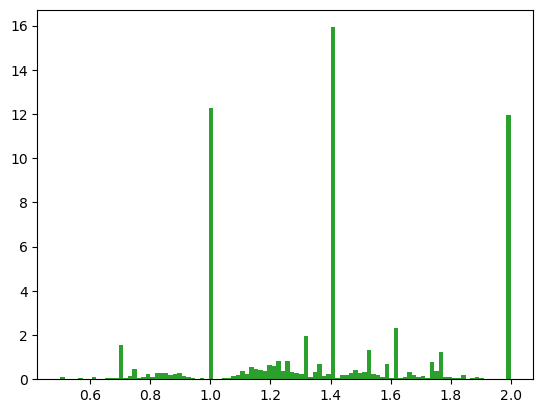

In [8]:
if __name__ == "__main__":
    main_order_distribution()